In [1]:
import numpy as np
import random 
import matplotlib.pyplot as plt

In [2]:
states = ['A', 'B', 'C', 'D', 'E']
terminal_states = ['A' , 'E'] 

In [3]:
num_states = len(states)
rewards =  [ 0 , 0 ,0 , 0 , 1] 
true_values = [1/6 , 2/6 , 3/6 , 4/6  , 5/6 ] 

In [4]:
transition_matrix = [
     [ 0 , 1 , 0 , 0 , 0 ] , 
     [ 0.5 , 0 , 0.5 , 0 , 0 ] , 
     [ 0 , 0.5 , 0 , 0.5 , 0 ] ,
     [ 0 , 0 , 0.5 , 0 , 0.5 ] ,
     [ 0 , 0 , 0 , 1 , 0 ] ,
]

In [5]:
def choose_random_non_zero(arr):
    # Create a list of indices corresponding to non-zero elements
    non_zero_indices = [i for i, value in enumerate(arr) if value != 0]
    random_index = random.choice(non_zero_indices)
    random_non_zero_number = arr[random_index]
    return random_non_zero_number, random_index

In [6]:
def td_0_random_walk(transition_matrix, rewards, num_episodes , alpha):
    value_function = [1/6,1/2,1/2,1/2,5/6]
    for _ in range(num_episodes) :
        current_state = 2  # corresponding to 'C'
        while (True) :
            probability_of_next_state , next_state = choose_random_non_zero(transition_matrix[current_state])
            reward  = rewards[current_state] 
            value_function[current_state] += alpha * (reward + value_function[next_state] - value_function[current_state])
            current_state = next_state
            if current_state == 0 or current_state == 4:
                break
    return value_function

In [7]:
x = td_0_random_walk(transition_matrix, rewards, num_episodes= 100 , alpha= 0.01)
x

[0.16666666666666666,
 0.3724856301210622,
 0.47471094797586955,
 0.5741352057628388,
 0.8333333333333334]

In [8]:
def RMS_calculator(observed_values): 
    true_values = [1/6 , 2/6 , 3/6 ,4/6 ,5/6]
    rms = 0 
    for i in range(len(observed_values)) : 
        rms += (observed_values[i] - true_values[i])**2
    rms = rms/5 
    rms = rms**0.5 
    return rms

In [21]:
alphas = { 0.01:[] , 0.02:[] , 0.03:[] , 0.04:[] , 0.05:[]   } 

In [22]:
for i in alphas.keys() :
    for j in range(1, 101):
        x = td_0_random_walk(transition_matrix, rewards, num_episodes= j , alpha= i )
        y = RMS_calculator(x)
        alphas[i].append(y)

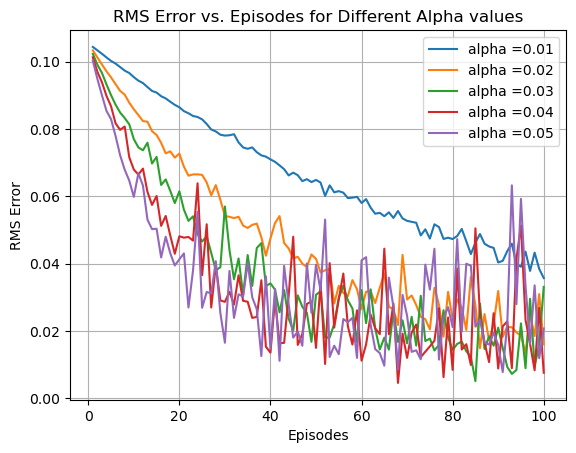

<Figure size 60000x40000 with 0 Axes>

In [23]:
# Sample list of elements (x values)
x = [i for i in range(1,101) ]
# Corresponding y values (you can replace this with your data)

for q in alphas.keys():
    l = "alpha =" + str(q) 
    plt.plot(x, alphas[q] , label = l )
    


plt.xlabel('Episodes')
plt.ylabel('RMS Error')
plt.legend()
plt.title('RMS Error vs. Episodes for Different Alpha values')
plt.grid(True)
plt.figure(figsize=(600, 400))
plt.show()